In [ ]:
import pandas as pd

In [ ]:
df5 = pd.read_csv('Dataset.csv')

In [ ]:
# Convert date_added to actual datetime
df5['date_added'] = pd.to_datetime(df5['date_added'], errors='coerce')

In [ ]:
# Drop rows where date couldn't be parsed
df5 = df5.dropna(subset=['date_added'])

In [ ]:
# Extract year and month
df5['year_added'] = df5['date_added'].dt.year
df5['month_added'] = df5['date_added'].dt.month
df5['year_month'] = df5['date_added'].dt.to_period('M')

print(df5[['title', 'date_added', 'year_added', 'month_added']].head())
print("\nDate range:", df5['date_added'].min(), "to", df5['date_added'].max())

                              title date_added  year_added  month_added
0              Dick Johnson Is Dead 2021-09-25        2021            9
1                         Ganglands 2021-09-24        2021            9
2                     Midnight Mass 2021-09-24        2021            9
3  Confessions of an Invisible Girl 2021-09-22        2021            9
4                           Sankofa 2021-09-24        2021            9

Date range: 2008-01-01 00:00:00 to 2021-09-25 00:00:00


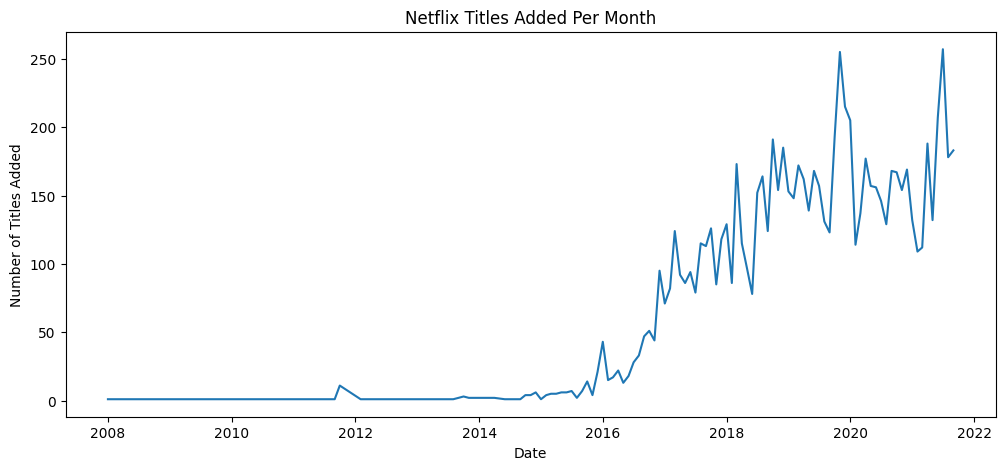

year_month
2020-10-01    167
2020-11-01    154
2020-12-01    169
2021-01-01    132
2021-02-01    109
2021-03-01    112
2021-04-01    188
2021-05-01    132
2021-06-01    207
2021-07-01    257
2021-08-01    178
2021-09-01    183
dtype: int64


In [ ]:
import matplotlib.pyplot as plt

# Count titles added per month
monthly_counts = df5.groupby('year_month').size()
monthly_counts.index = monthly_counts.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(monthly_counts.index, monthly_counts.values)
plt.title('Netflix Titles Added Per Month')
plt.xlabel('Date')
plt.ylabel('Number of Titles Added')
plt.show()

print(monthly_counts.tail(12))

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Prepare the series
ts = monthly_counts.reset_index()
ts.columns = ['date', 'count']
ts['time_index'] = np.arange(len(ts))  # 0, 1, 2, 3... one per month

# Split: use last 6 months as test set
train = ts[:-6]
test = ts[-6:]

# Model 1: Linear Regression on time index
lr_model = LinearRegression()
lr_model.fit(train[['time_index']], train['count'])
lr_preds = lr_model.predict(test[['time_index']])

# Model 2: Simple moving average baseline (average of last 3 months of train, repeated)
moving_avg = train['count'].tail(3).mean()
ma_preds = [moving_avg] * len(test)

print("Actual test values:", test['count'].values)
print("Linear Regression predictions:", lr_preds.round(1))
print("Moving Average predictions:", np.round(ma_preds, 1))

Actual test values: [188 132 207 257 178 183]
Linear Regression predictions: [185.8 188.  190.1 192.3 194.4 196.6]
Moving Average predictions: [117.7 117.7 117.7 117.7 117.7 117.7]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


        date  predicted_titles_added
0 2021-10-01                   199.0
1 2021-11-01                   201.0
2 2021-12-01                   203.0
3 2022-01-01                   205.0
4 2022-02-01                   207.0
5 2022-03-01                   209.0


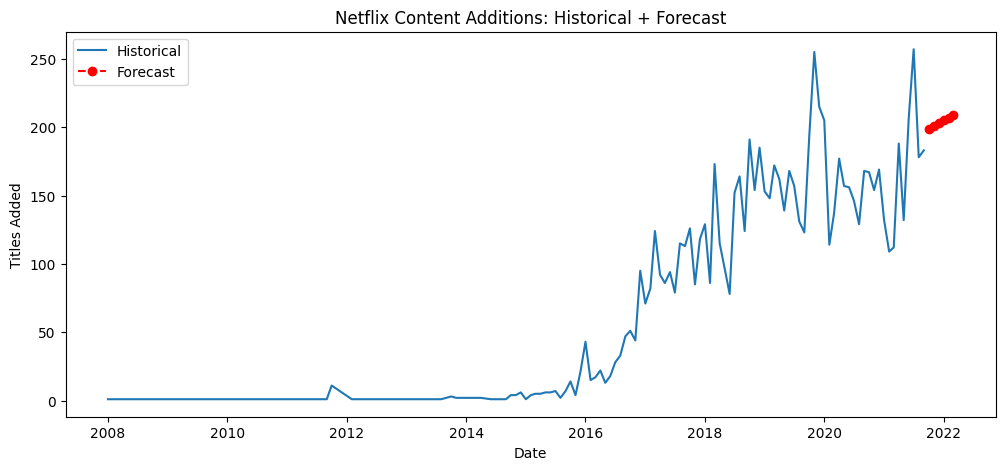

In [ ]:
# Retrain linear regression on ALL available data (not just train split)
lr_final = LinearRegression()
lr_final.fit(ts[['time_index']], ts['count'])

# Generate the next 6 months' time indices
future_steps = 6
future_index = np.arange(len(ts), len(ts) + future_steps)
future_preds = lr_final.predict(future_index.reshape(-1, 1))

# Build future dates for readability
last_date = ts['date'].max()
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='MS')[1:]

forecast_df = pd.DataFrame({
    'date': future_dates,
    'predicted_titles_added': future_preds.round(0)
})

print(forecast_df)

# Plot history + forecast
plt.figure(figsize=(12,5))
plt.plot(ts['date'], ts['count'], label='Historical')
plt.plot(forecast_df['date'], forecast_df['predicted_titles_added'], label='Forecast', linestyle='--', marker='o', color='red')
plt.title('Netflix Content Additions: Historical + Forecast')
plt.xlabel('Date')
plt.ylabel('Titles Added')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate on the held-out test set from Step 3
lr_mae = mean_absolute_error(test['count'], lr_preds)
lr_rmse = np.sqrt(mean_squared_error(test['count'], lr_preds))

ma_mae = mean_absolute_error(test['count'], ma_preds)
ma_rmse = np.sqrt(mean_squared_error(test['count'], ma_preds))

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Moving Average'],
    'MAE': [lr_mae, ma_mae],
    'RMSE': [lr_rmse, ma_rmse]
})

print(results)

               Model        MAE       RMSE
0  Linear Regression  28.294038  36.664822
1     Moving Average  73.166667  82.112727
